# Climate sensitivity to the solar constant 

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

plt.rcParams.update({
    'figure.figsize': (8, 5),
    'lines.linewidth': 2,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.constrained_layout.use': True,
    'savefig.dpi': 300,     
    'savefig.bbox': 'tight'
})

from pathlib import Path

from ebm1d import EBM1DBudyko
from ebm1d import load_config
from ebm1d import load_input_data

ROOT_DIR = Path.cwd().parent
results_dir = ROOT_DIR / "results" / "climate_sens_S0"
results_dir.mkdir(parents=True, exist_ok=True)

# Load configuration and input dataset
config = load_config(ROOT_DIR / "configs" / "default.toml")
inputs = load_input_data(config.input.dataset, config.model.n_lat)
print("Configuration loaded successfully.")

YEAR_IN_DAYS = EBM1DBudyko.YEAR_IN_DAYS
# Reference value for the solar constant (S0) from the configuration
S0_REF = config.insolation.S0
print(f"Solar constant reference value from the configuration: {S0_REF} W/m²")

# Initialize the EBM model with seasonal forcing
ebm_seasonal = EBM1DBudyko(config, inputs, seasonal=True)
lat_deg = ebm_seasonal.lat_centers_deg

Configuration loaded successfully.
Solar constant reference value from the configuration: 1368.0 W/m²
Initializing the 1D EBM with 18 latitude band and seasonal insolation = True


In [2]:
# Integrate the model for the reference case
ebm_seasonal.S0 = S0_REF # Set S0 to the reference value
t_days_ref, history_ref, info = ebm_seasonal.integrate(
    dt_days=1.0,
    n_years=20
)

# Now, we will Increase S0 by 5% compared to the reference value and integrate the model
S0_05 = S0_REF * 1.05
ebm_seasonal.S0 = S0_05

t_days_05, history_05, info_05 = ebm_seasonal.integrate(
    dt_days=1.0,
    n_years=20
)


def print_convergence_info(model, info):
    if info['converged']:
        print(f"{model} has converged. Final state reached at t = {info['t_final_years']} " 
              f"years after {info['steps_per_year'] * info['t_final_years']} steps.")
    else:
        print(f"{model} has not converged !")


print_convergence_info("Reference scenario", info)
print_convergence_info("S0*1.05 scenario", info_05)

steps_per_year = info['steps_per_year'] 
T_last_year_ref = history_ref[-steps_per_year:]
T_last_year_05 = history_05[-steps_per_year:]

Reference scenario has converged. Final state reached at t = 20.0 years after 7300.0 steps.
S0*1.05 scenario has converged. Final state reached at t = 20.0 years after 7300.0 steps.


## Let’s compare the current climate to an $S_0 + 5\%$ scenario

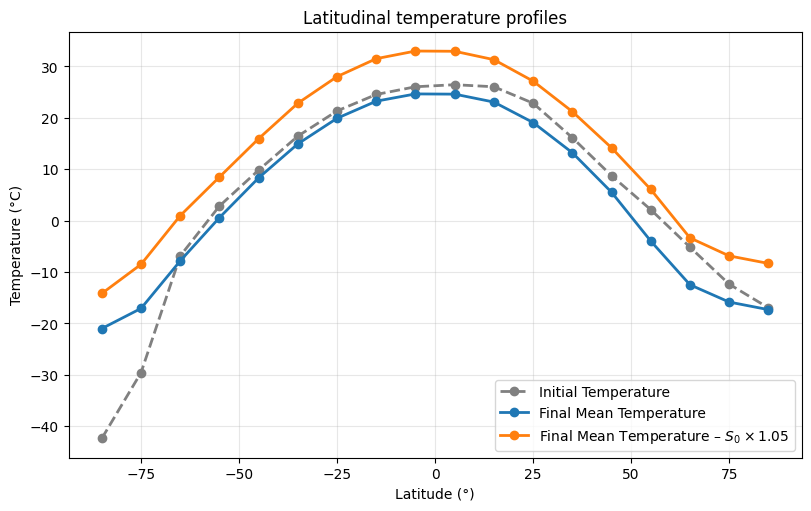

Global mean temperature for S0 = 1368.0 W/m²: 12.18 °C
Global mean temperature for S0 = 1436.4 W/m²: 20.50 °C


In [3]:
T_last_year_ref_mean = T_last_year_ref.mean(axis=0)
T_last_year_05_mean = T_last_year_05.mean(axis=0)
T_global_mean_last_year = ebm_seasonal.global_temperature(T_last_year_ref_mean)
T_global_mean_last_year_05 = ebm_seasonal.global_temperature(T_last_year_05_mean)

fig, ax = plt.subplots()
ax.plot(lat_deg, ebm_seasonal.input_data.T0 - 273.15, label="Initial Temperature", ls='--', marker='o', color='gray')
ax.plot(lat_deg, T_last_year_ref_mean - 273.15, label="Final Mean Temperature", marker='o')
ax.plot(lat_deg, T_last_year_05_mean - 273.15, label=r"Final Mean Temperature – $S_0 \times 1.05$", marker='o')
ax.set_xlabel("Latitude (°)")
ax.set_ylabel("Temperature (°C)")
ax.set_title("Latitudinal temperature profiles")
ax.legend()
ax.grid(True)
fig.savefig(results_dir / "latitudinal_temperature_profiles.png")
plt.show()

print(f"Global mean temperature for S0 = {S0_REF:.1f} W/m²: {T_global_mean_last_year - 273.15:.2f} °C")
print(f"Global mean temperature for S0 = {S0_05:.1f} W/m²: {T_global_mean_last_year_05 - 273.15:.2f} °C")

### How does this affect the ice fraction?

In [4]:
# Compute the fraction of land, ocean, and ice for the last year of both integrations
f_land = ebm_seasonal.input_data.f_land
f_ocean = 1 - f_land

f_ice_ref = ebm_seasonal.compute_fraction_ice(T_last_year_ref)
f_ice_05 = ebm_seasonal.compute_fraction_ice(T_last_year_05)

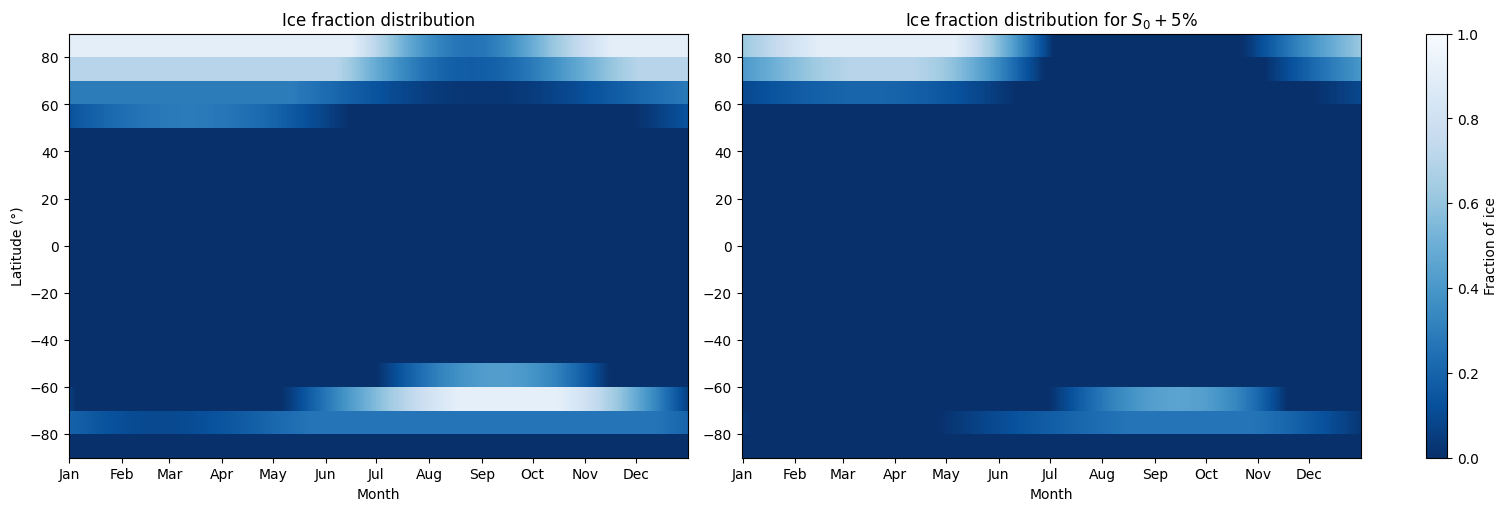

In [5]:

days = np.arange(0, YEAR_IN_DAYS, YEAR_IN_DAYS/steps_per_year)
days_in_month = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
month_starts = np.cumsum([0] + days_in_month[:-1]) # We start from 0 to match the day counting
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Heatmap of the ice fraction distribution over the last year for both integrations
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
im1 = axes[0].pcolormesh(
    days,
    lat_deg,
    (f_ice_ref*f_ocean).T,
    shading='auto',
    cmap='Blues_r',
    vmin=0, vmax=1
)
im2 = axes[1].pcolormesh(
    days,
    lat_deg,
    (f_ice_05*f_ocean).T,
    shading='auto',
    cmap='Blues_r',
    vmin=0, vmax=1
)
cbar = fig.colorbar(im1, ax=axes)
cbar.set_label("Fraction of ice")
for ax in axes:
    ax.set_xticks(month_starts)
    ax.set_xticklabels(month_labels)
    ax.set_xlabel("Month")
    ax.grid(False)
axes[0].set_ylabel("Latitude (°)")
axes[0].set_title("Ice fraction distribution")
axes[1].set_title(r"Ice fraction distribution for $S_0 + 5\%$")
plt.savefig(results_dir / "ice_fraction_distribution.png")
plt.show()

### How the temperature increase is distributed?

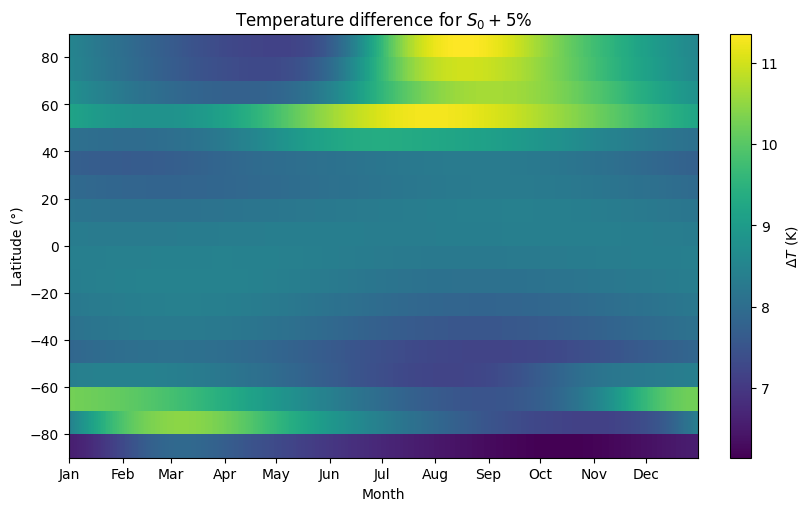

In [6]:

delta_T_05 = T_last_year_05 - T_last_year_ref

fig, ax = plt.subplots()
im = ax.pcolormesh(
    days,
    lat_deg,
    delta_T_05.T,
    shading='auto'
)
cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r"$\Delta T$ (K)")
ax.set_xticks(month_starts)
ax.set_xticklabels(month_labels)
ax.set_xlabel("Month")
ax.set_ylabel("Latitude (°)")
ax.set_title(r"Temperature difference for $S_0 + 5\%$")
ax.grid(False)
plt.savefig(results_dir / "temperature_difference.png")
plt.show()


---

## Investigation of the climate response for different values of the solar constant

In particular, we will examine how the latitudinal extent of the ice changes as a function of $S_0$. This will shed light on the Snowball Earth state.

In [7]:
S0 = np.unique(np.append(np.arange(500, 2801, 100, dtype=float), S0_REF))

T_global_mean_last_year = np.zeros(len(S0))
albedo_mean_last_year = np.zeros((len(S0), ebm_seasonal.n_lat))
f_ice_last_year = np.zeros((len(S0), steps_per_year, ebm_seasonal.n_lat))


for i, S0_value in enumerate(S0):
    ebm_seasonal.S0 = S0_value
    t_days, history, info = ebm_seasonal.integrate(
        stop_at_convergence=True,
        n_years=100,
        dt_days=1.0,
        min_years=10.0
    )
    T_last_year = history[-steps_per_year:]
    T_last_year_mean = T_last_year.mean(axis=0)
    T_global_mean_last_year[i] = ebm_seasonal.global_temperature(T_last_year_mean)
    albedo_mean_last_year[i] = ebm_seasonal.compute_albedo(T_last_year_mean)
    f_ice_last_year[i] = ebm_seasonal.compute_fraction_ice(T_last_year)

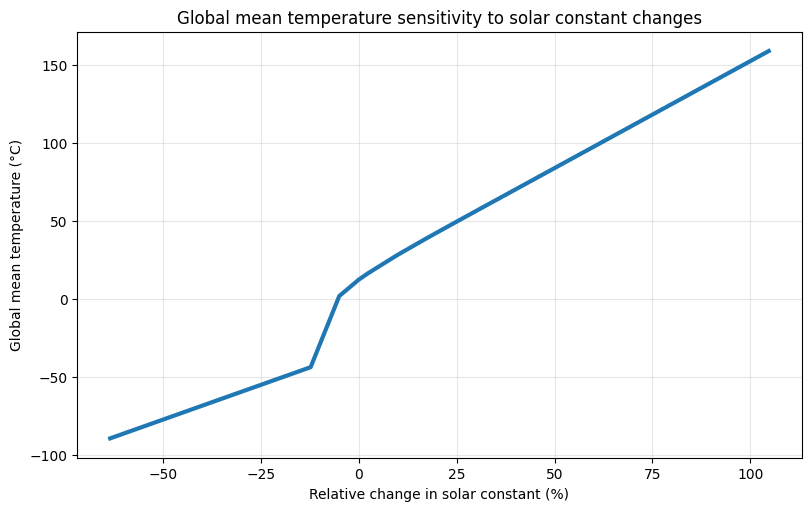

In [8]:
fig, ax = plt.subplots()
ax.plot((S0-S0_REF)*100/S0_REF, T_global_mean_last_year - 273.15, lw=3)
ax.set_xlabel("Relative change in solar constant (%)")
ax.set_ylabel("Global mean temperature (°C)")
ax.set_title("Global mean temperature sensitivity to solar constant changes")
fig.savefig(results_dir / "global_mean_temperature_sensitivity.png")
plt.show()

In [9]:
# We define a function to determine the latitude limits of ice coverage based on the fraction of ice and a specified threshold. 
# The function takes the fraction of ice (f_ice) and the corresponding latitudes (lat_deg) as inputs, along with an optional threshold.
def get_ice_limits(f_ice, lat_deg, threshold=0.5):
    if f_ice.shape != lat_deg.shape:
        raise ValueError("Length of f_ice must match the number of latitudes.")

    # Separate the ice fractions and latitudes for the Southern and Northern Hemispheres
    f_ice_sh = f_ice[lat_deg < 0]
    f_ice_nh = f_ice[lat_deg >= 0]

    # Separate the latitudes for the Southern and Northern Hemispheres
    lat_sh = lat_deg[lat_deg < 0]
    lat_nh = lat_deg[lat_deg >= 0]

    # Assuming uniform latitude spacing, calculate half the band width for edge cases
    half_band = (lat_deg[1] - lat_deg[0]) / 2.0 

    # Find the latitude index where f_ice exceeds the threshold in the Southern Hemisphere (starting from the pole)    
    limit_sh_idx = None
    for i in range(len(f_ice_sh)-1, -1, -1):
        if f_ice_sh[i] > threshold:
            limit_sh_idx = i
            break
    
    # Find the latitude index where f_ice exceeds the threshold in the Northern Hemisphere (starting from the pole)
    limit_nh_idx = None
    for i in range(len(f_ice_nh)):
        if f_ice_nh[i] > threshold:
            limit_nh_idx = i
            break
        
    # Get the corresponding latitude limits
    if limit_sh_idx is not None:
        limit_sh = lat_sh[limit_sh_idx] + half_band
    else:
        limit_sh = lat_sh[0] - half_band  # no ice in SH: beyond the poleward edge

    if limit_nh_idx is not None:
        limit_nh = lat_nh[limit_nh_idx] - half_band
    else:
        limit_nh = lat_nh[-1] + half_band  # no ice in NH: beyond the poleward edge

    return limit_sh, limit_nh

In [10]:
# limitss[i, j] = (sh_limit, nh_limit) for S0[i], timestep j → shape: (n_S0, steps_per_year, 2)
limits = np.array([[get_ice_limits(f_ice_last_year[i, j], lat_deg)
                  for j in range(steps_per_year)]
                  for i in range(len(S0))])

# DataFrame to store the minimum and maximum latitude limits of ice coverage for both hemispheres across all S0 values and time steps.
limits_min_max = pd.DataFrame({
    'S0': S0,
    'SH_min': limits[:, :, 0].min(axis=1),
    'SH_max': limits[:, :, 0].max(axis=1),
    'NH_min': limits[:, :, 1].min(axis=1),
    'NH_max': limits[:, :, 1].max(axis=1),
})

# We check if there are any rows where all limits are 0, which would indicate that the ice coverage is permanently at the equator.
data_cols = ['SH_min', 'SH_max', 'NH_min', 'NH_max']
is_equator = np.isclose(limits_min_max[data_cols], 0).all(axis=1)

# If such rows exist, we keep only the last one
if is_equator.any():
    limits_min_max = pd.concat([
        limits_min_max[is_equator].tail(1),  # Keep only the last row where all limits are 0
        limits_min_max[~is_equator] # Keep all rows where limits are not all 0
    ]).reset_index(drop=True)

print("Latitude limits of ice coverage:")
print(limits_min_max.head(10).round(1))

Latitude limits of ice coverage:
       S0  SH_min  SH_max  NH_min  NH_max
0  1200.0     0.0     0.0    -0.0    -0.0
1  1300.0   -60.0   -40.0    40.0    60.0
2  1368.0   -80.0   -60.0    50.0    90.0
3  1400.0   -90.0   -60.0    60.0    90.0
4  1500.0   -90.0   -70.0    70.0    90.0
5  1600.0   -90.0   -90.0    90.0    90.0
6  1700.0   -90.0   -90.0    90.0    90.0
7  1800.0   -90.0   -90.0    90.0    90.0
8  1900.0   -90.0   -90.0    90.0    90.0
9  2000.0   -90.0   -90.0    90.0    90.0


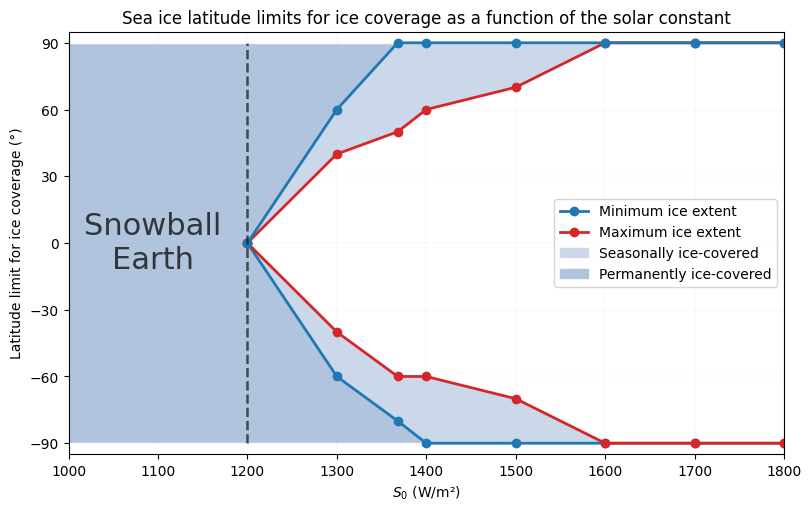

In [11]:
# We plot the latitude limits of ice coverage for both hemispheres as a function of the solar constant (S0).
fig, ax = plt.subplots()
x_lim = (1000, 1800)
y_lim = (-95, 95)
y_ticks = np.arange(-90, 91, 30)

ax.plot(limits_min_max['S0'], limits_min_max['SH_min'], marker='o', label="Minimum ice extent", color='tab:blue')
ax.plot(limits_min_max['S0'], limits_min_max['SH_max'], marker='o', label="Maximum ice extent", color='tab:red')
ax.plot(limits_min_max['S0'], limits_min_max['NH_min'], marker='o', color='tab:red')
ax.plot(limits_min_max['S0'], limits_min_max['NH_max'], marker='o', color='tab:blue')

# We add a vertical dashed line to indicate the solar constant value at which the snowball Earth state occurs, which is the minimum S0 value in our dataset.
S0_snowball = limits_min_max['S0'].min()
ax.vlines(S0_snowball, -90, 90, color='#191a1bd5', alpha=0.73, ls='--', linewidth=1.8)
# We add a text annotation to label the snowball Earth state on the plot, placing it near the vertical dashed line for clarity.
ax.text((S0_snowball+x_lim[0])/2, 0, "Snowball \nEarth ", color='#191a1bd5', fontsize=22, ha='center', va='center')

ax.set_facecolor(color='lightsteelblue')
patch_ice_covered = Patch(color='#b0c4de', label="Permanently ice-covered")

# Fill in the areas without ice with white
ax.fill_between(limits_min_max['S0'], limits_min_max['SH_max'], limits_min_max['NH_min'], alpha=1, color='white')
ax.axhspan(90, 95, color='white', alpha=1)
ax.axhspan(-90, -95, color='white', alpha=1)

# We fill the area between the minimum and maximum latitude limits of ice coverage for both hemispheres to visually represent the regions that are seasonally ice-covered.
ax.fill_between(limits_min_max['S0'], limits_min_max['SH_min'], limits_min_max['SH_max'], alpha=1, color='#cbd8e9', label="Seasonally ice-covered")
ax.fill_between(limits_min_max['S0'], limits_min_max['NH_min'], limits_min_max['NH_max'], alpha=1, color='#cbd8e9')

ax.set(
    xlim=x_lim,
    ylim=y_lim,
    xlabel="$S_0$ (W/m²)",
    ylabel="Latitude limit for ice coverage (°)",
    yticks=y_ticks,
    title="Sea ice latitude limits for ice coverage as a function of the solar constant"
)

ax.grid(True, alpha=0.2, linewidth=0.3)

handles, labels = ax.get_legend_handles_labels()
handles.append(patch_ice_covered)
labels.append(patch_ice_covered.get_label())
ax.legend(handles=handles, labels=labels)
fig.savefig(results_dir / "ice_coverage_limits.png")
plt.show()

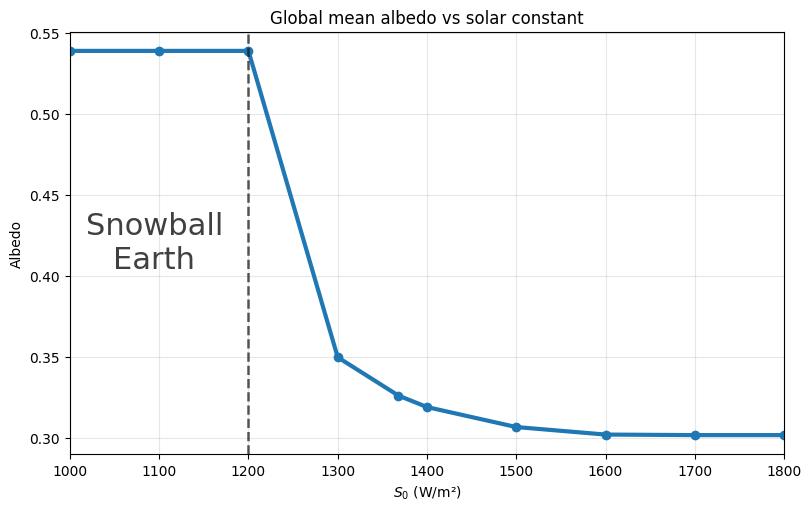

In [12]:
f_area = ebm_seasonal.f_area
albedo_global_mean_last_year = albedo_mean_last_year @ f_area

# We plot the global mean albedo as a function of S0
fig, ax = plt.subplots()
ax.plot(S0, albedo_global_mean_last_year, label="Global mean albedo", marker='o', lw=3)
# We add a vertical dashed line to indicate the solar constant value at which the snowball Earth state occurs, which is the minimum S0 value in our dataset.
S0_snowball = limits_min_max['S0'].min()
ax.axvline(S0_snowball, color='#191a1bd5', alpha=0.73, ls='--', linewidth=1.8)
# We add a text annotation to label the snowball Earth state on the plot, placing it near the vertical dashed line for clarity.
x_pos = (((S0_snowball + x_lim[0]) / 2) - x_lim[0]) / (x_lim[1] - x_lim[0])
ax.text(x_pos, 0.5, "Snowball \nEarth ", transform=ax.transAxes, color='#191a1bd5', fontsize=22, ha='center', va='center')

ax.set(
     xlim=x_lim,
     xlabel="$S_0$ (W/m²)",
     ylabel="Albedo",
     title="Global mean albedo vs solar constant"
)
fig.savefig(results_dir / "global_mean_albedo_sensitivity.png")
plt.show()



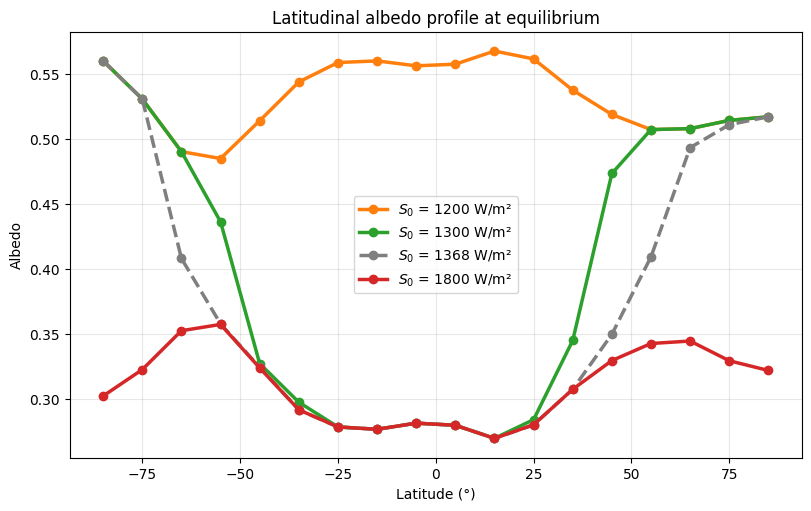

In [17]:
selected_indices = [7, 8, 9, 14] #selcted_index or selected_indices ? what do you 
colors = ['tab:orange', 'tab:green', 'tab:gray', 'tab:red']
ls = ['-', '-', '--', '-']


fig, ax = plt.subplots()
for i, idx in enumerate(selected_indices):
    ax.plot(lat_deg, albedo_mean_last_year[idx], label=f"$S_0$ = {S0[idx]:.0f} W/m²", marker='o', color=colors[i], lw=2.5, ls=ls[i])
ax.set_xlabel("Latitude (°)")
ax.set_ylabel("Albedo")
ax.set_title("Latitudinal albedo profile at equilibrium")
ax.legend(loc='center')
fig.savefig(results_dir / "latitudinal_albedo_profiles.png")
plt.show()